# PHM 678 — Quantum Kernel Classification Project
**Spring 2026 · Quantum Machine Learning and Artificial Intelligence**

Prof. Dr. Salah Eldin Hassan Gamal Eldin

---
This notebook walks through all five project parts end-to-end:
- **Part 1** — Theoretical background and dataset overview
- **Part 2** — Quantum feature map circuits
- **Part 3** — Kernel matrix computation and heatmaps
- **Part 4** — QSVM vs classical SVM benchmark
- **Part 5** — Angle embedding with PCA

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans'})
print('Environment ready.')

Environment ready.


---
## Part 1 — Theoretical Background

### Key Concepts

**Quantum feature map** `U(x)`: a parametrized quantum circuit that maps a classical vector `x ∈ Rᵈ` to a quantum state:

$$|\phi(x)\rangle = U(x)|0\rangle$$

**Quantum kernel**: the squared overlap (fidelity) between two encoded states:

$$K(x, z) = |\langle\phi(x)|\phi(z)\rangle|^2$$

This is estimated via the **compute-uncompute** circuit:
1. Prepare $|\phi(x)\rangle$ by running $U(x)$
2. Apply the inverse $U(z)^\dagger$
3. Measure the probability of the all-zeros bitstring $|0\rangle^{\otimes n}$
4. That probability $= |\langle\phi(x)|\phi(z)\rangle|^2$

**Why does this matter?**  
The kernel matrix $K_{ij} = K(x_i, x_j)$ is symmetric and positive semi-definite, so it drops directly into sklearn's `SVC(kernel='precomputed')`. The SVM then finds the maximum-margin hyperplane in the quantum Hilbert space without ever computing the full $2^n$-dimensional state vector explicitly.

In [2]:
# ── Dataset ────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

data = load_breast_cancer()
X_raw, y_raw = data.data, np.where(data.target == 0, -1, 1)

print('Breast Cancer Wisconsin Dataset')
print(f'  Samples  : {len(X_raw)}')
print(f'  Features : {X_raw.shape[1]}')
print(f'  Malignant: {(y_raw == -1).sum()}  |  Benign: {(y_raw == 1).sum()}')
pd.DataFrame(X_raw, columns=data.feature_names).describe().round(2)

Breast Cancer Wisconsin Dataset
  Samples  : 569
  Features : 30
  Malignant: 212  |  Benign: 357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


In [3]:
# ── Preprocessing ──────────────────────────────────────────────
N_FEATURES = X_raw.shape[1]          # qubits = PCA components
MAX_TRAIN  = 80         # cap for O(n²) quantum kernel computation
MAX_TEST   = 40

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

# Subsample for quantum parts
rng = np.random.default_rng(42)
idx_tr = rng.choice(len(X_tr), size=MAX_TRAIN, replace=False)
X_tr_q, y_tr_q = X_tr[idx_tr], y_tr[idx_tr]
X_te_q, y_te_q = X_te[:MAX_TEST], y_te[:MAX_TEST]

PCA
pca = PCA(n_components=N_FEATURES, random_state=42)
X_tr_q = pca.fit_transform(X_tr_q)
X_te_q = pca.transform(X_te_q)

# Scale to [0, π]
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_tr_q = scaler.fit_transform(X_tr_q)
X_te_q = scaler.transform(X_te_q)

print(f'Train size (quantum): {len(X_tr_q)}  |  Test size: {len(X_te_q)}')
print(f'PCA explained variance: {pca.explained_variance_ratio_ * 100}')
print(f'Total retained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Train size (quantum): 80  |  Test size: 40
PCA explained variance: [9.82130156e+01 1.71483198e+00 5.10965430e-02 1.47660173e-02
 5.20075639e-03 7.05326759e-04 2.82268696e-04 4.71645338e-05
 2.45999497e-05 1.60303256e-05 9.78104754e-06 2.00697433e-06
 8.41598377e-07 5.12771344e-07 2.61854469e-07 1.24615928e-07
 7.98413964e-08 4.33919425e-08 3.85962991e-08 2.33155227e-08
 1.23385147e-08 1.07252874e-08 7.30989302e-09 3.16611644e-09
 2.22503367e-09 1.17553883e-09 6.14885986e-10 3.57913413e-10
 2.61485421e-10 1.44146298e-10]
Total retained: 100.0%


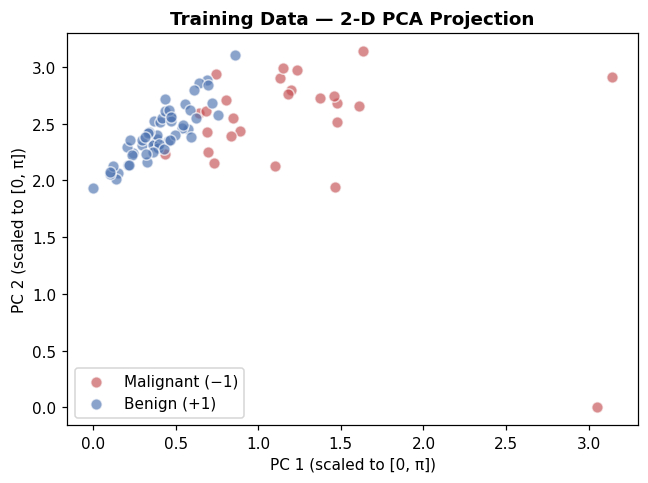

In [4]:
# PCA scatter
fig, ax = plt.subplots(figsize=(6, 4.5))
for lbl, color, name in [(-1, '#C44E52', 'Malignant (−1)'), (1, '#4C72B0', 'Benign (+1)')]:
    m = y_tr_q == lbl
    ax.scatter(X_tr_q[m, 0], X_tr_q[m, 1], c=color, label=name,
               alpha=0.65, edgecolors='white', s=55)
ax.set_xlabel('PC 1 (scaled to [0, π])')
ax.set_ylabel('PC 2 (scaled to [0, π])')
ax.set_title('Training Data — 2-D PCA Projection', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.savefig('results/pca_scatter.png', bbox_inches='tight')
plt.show()

---
## Part 2 — Quantum Feature Maps

We implement two feature maps:

| Map | Gates | Entanglement |
|-----|-------|--------------|
| **BasicFeatureMap** | H → RZ(xᵢ) → RX(xᵢ) per qubit | None |
| **ZZFeatureMap** | H → RZ(2xᵢ) → CX → RZ(2(π−xᵢ)(π−xⱼ)) → CX | Full pairwise |

In [9]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap

# ── Feature Map 1: Basic (no entanglement) ─────────────────────
def build_basic_feature_map(n: int) -> QuantumCircuit:
    """H → RZ(xᵢ) → RX(xᵢ) per qubit. No entanglement."""
    x = ParameterVector('x', length=n)
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.h(i)
        qc.rz(x[i], i)
        qc.rx(x[i], i)
    qc.name = 'BasicFM'
    return qc

# ── Feature Map 2: ZZFeatureMap (entangled) ───────────────────
def build_zz_feature_map(n: int, reps: int = 2) -> QuantumCircuit:
    """Qiskit ZZFeatureMap with pairwise CX entanglement."""
    qc = ZZFeatureMap(feature_dimension=n, reps=reps)
    qc.name = 'ZZFeatureMap'
    return qc

fmap_basic = build_basic_feature_map(N_FEATURES)
fmap_zz    = build_zz_feature_map(N_FEATURES, reps=2)

print('BasicFM    — qubits:', fmap_basic.num_qubits,
      ' params:', fmap_basic.num_parameters, ' depth:', fmap_basic.depth())
print('ZZFeatureMap — qubits:', fmap_zz.num_qubits,
      ' params:', fmap_zz.num_parameters, ' depth:', fmap_zz.depth())

BasicFM    — qubits: 30  params: 30  depth: 3
ZZFeatureMap — qubits: 30  params: 30  depth: 1


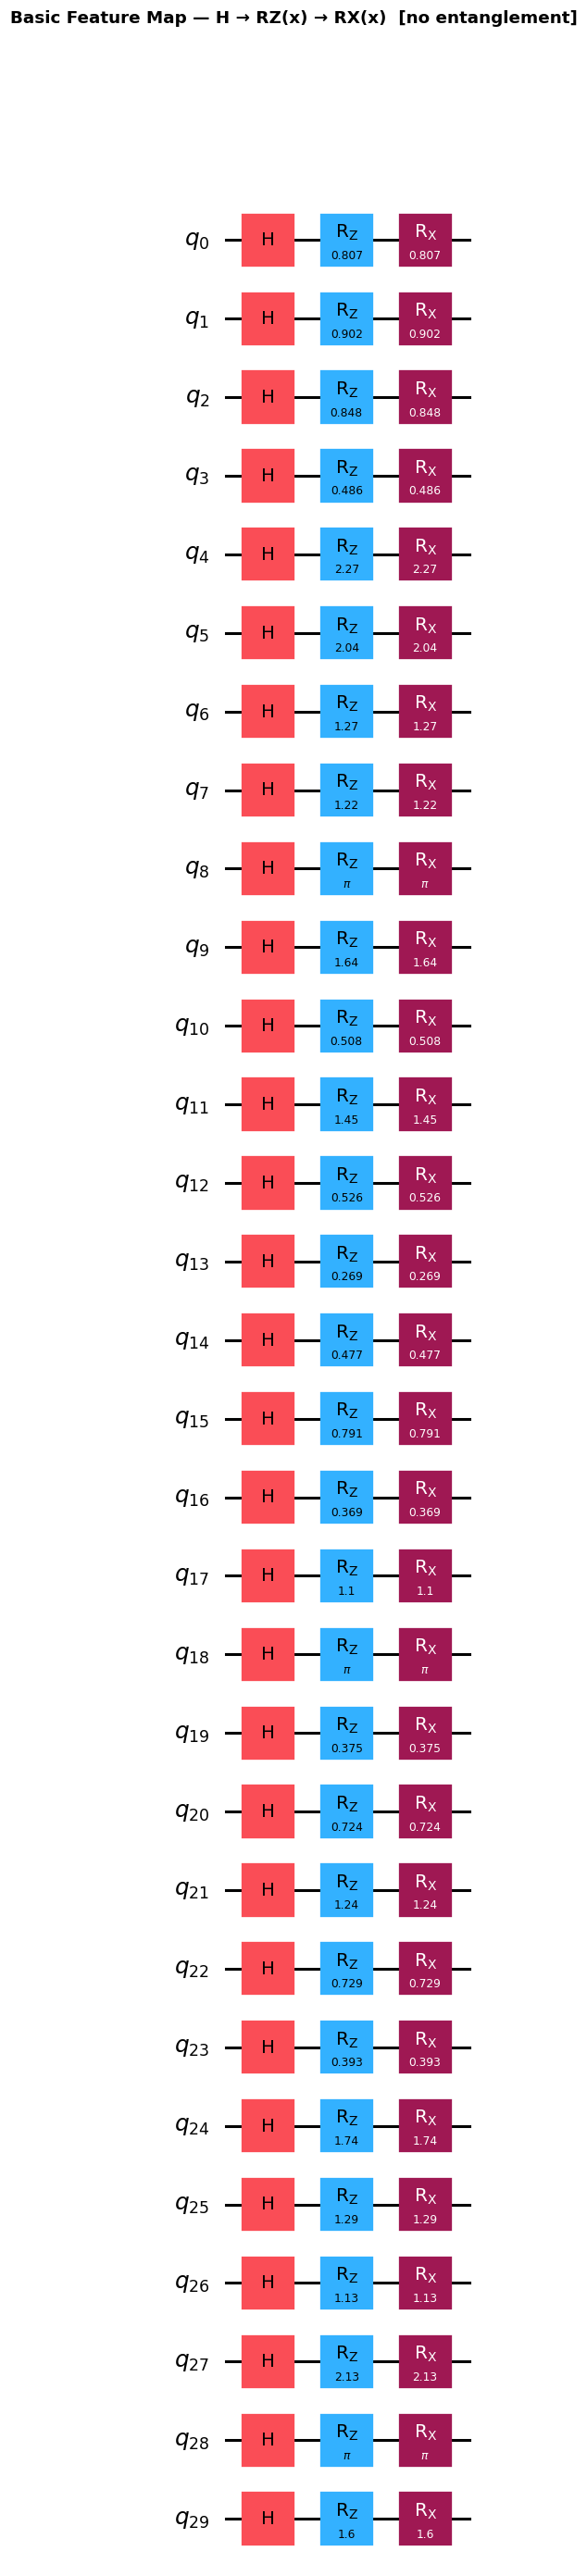

In [10]:
# Draw Basic Feature Map (bound to one sample)
sample = X_tr_q[0]
bound_basic = fmap_basic.assign_parameters(dict(zip(fmap_basic.parameters, sample)))
fig = bound_basic.draw(output='mpl', style='iqp', fold=-1)
fig.suptitle('Basic Feature Map — H → RZ(x) → RX(x)  [no entanglement]',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('results/circuit_basic.png', bbox_inches='tight')
plt.show()

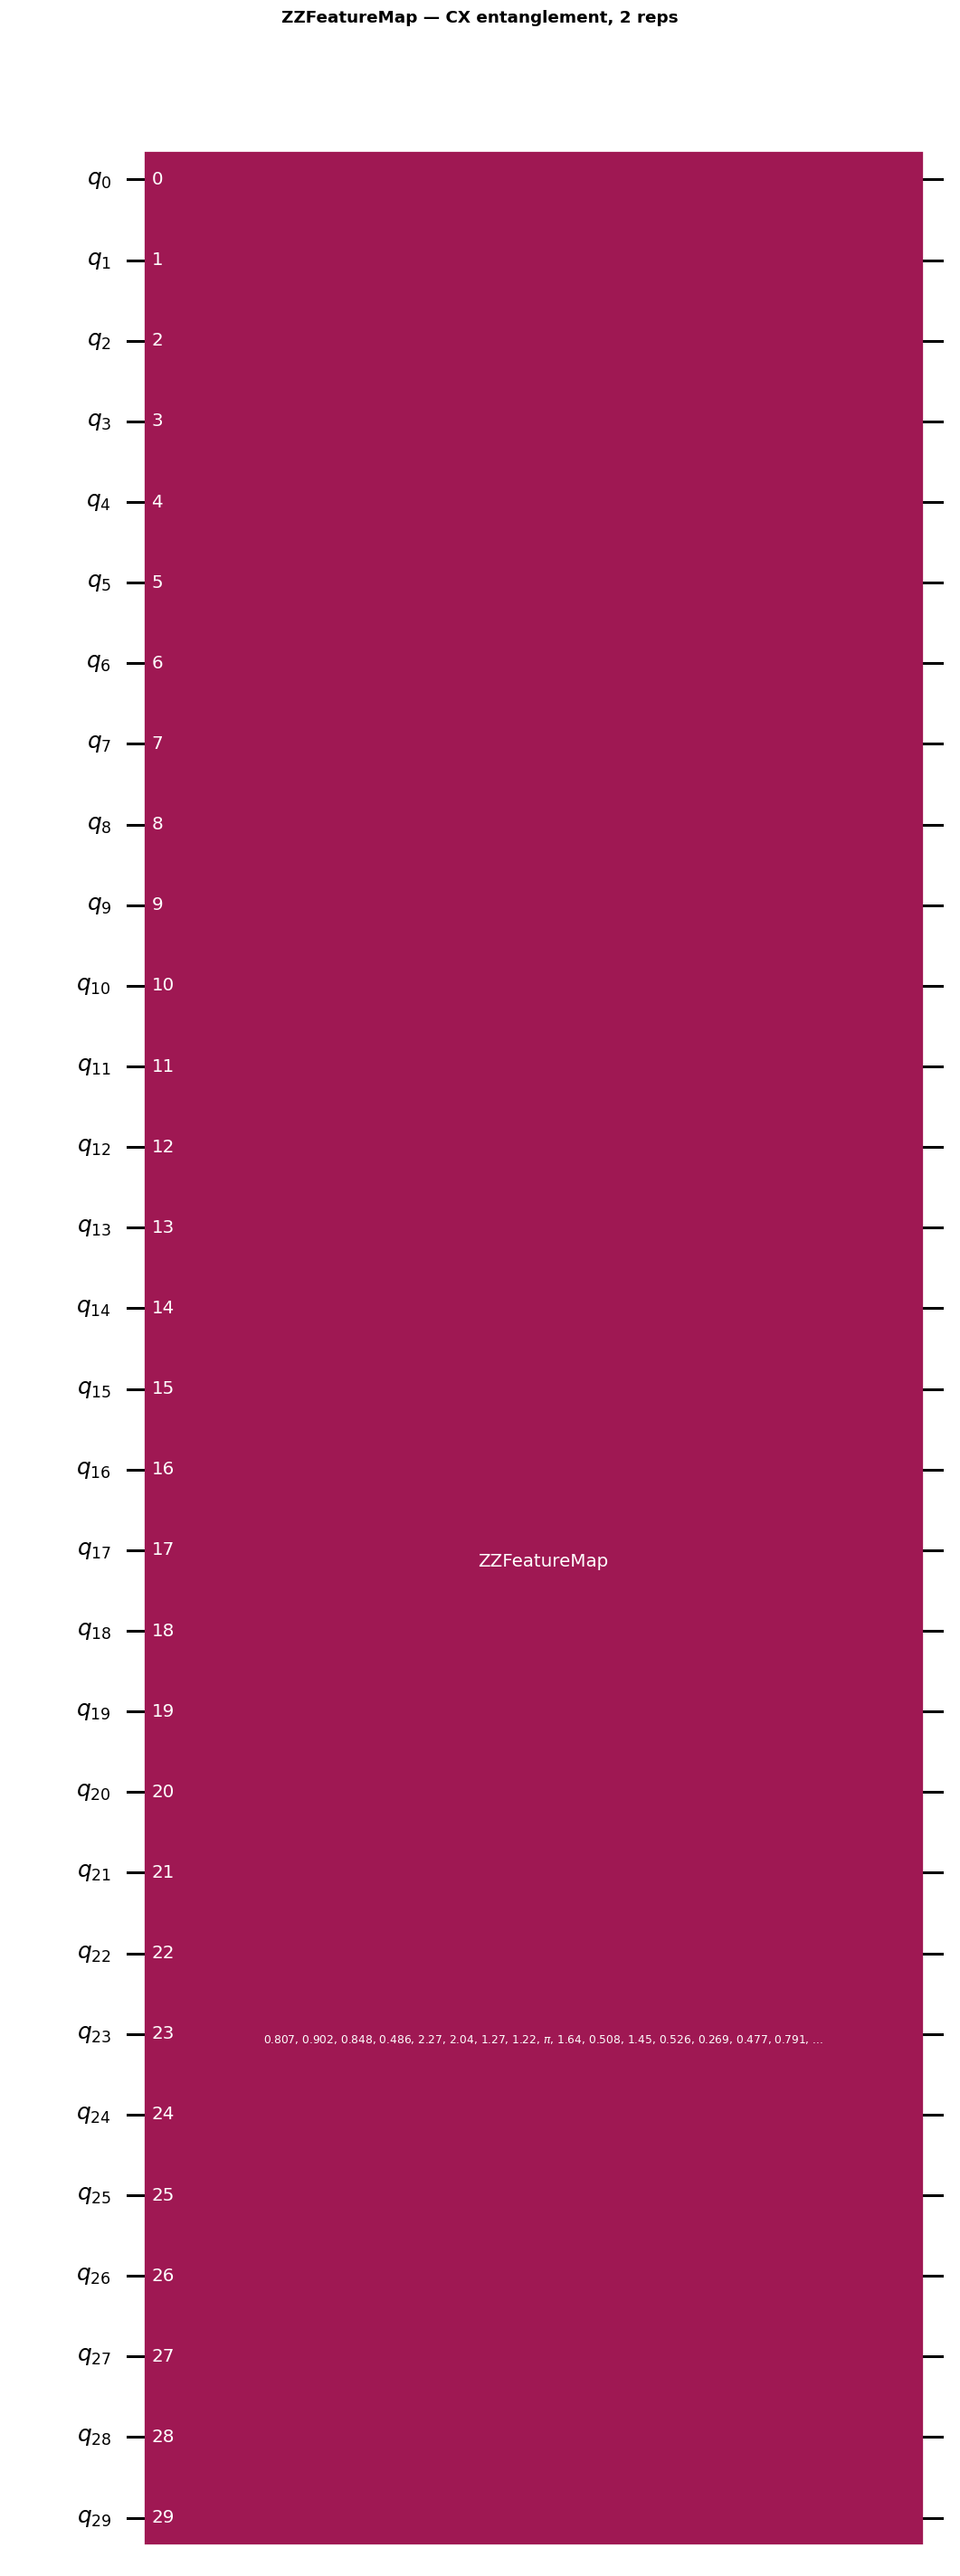

In [11]:
# Draw ZZFeatureMap (bound to same sample)
bound_zz = fmap_zz.assign_parameters(dict(zip(fmap_zz.parameters, sample)))
fig = bound_zz.draw(output='mpl', style='iqp', fold=-1)
fig.suptitle('ZZFeatureMap — CX entanglement, 2 reps',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('results/circuit_entangled.png', bbox_inches='tight')
plt.show()

### Design Intuition

**BasicFeatureMap** places each qubit at an arbitrary point on the Bloch sphere, using `xᵢ` as both the Z-rotation and X-rotation angle. The two-gate encoding gives more expressivity than a single rotation, but because qubits never interact, the kernel treats each feature independently. The resulting kernel is equivalent to a classical kernel that separates features additively.

**ZZFeatureMap** introduces the ZZ interaction term: after encoding individual features with `RZ(2xᵢ)`, it applies a `CX → RZ(2(π−xᵢ)(π−xⱼ)) → CX` block for each qubit pair. This term is large when `xᵢ` and `xⱼ` differ from `π` by similar amounts, and near zero when they differ from `π` by opposite amounts. The kernel therefore becomes sensitive to whether two data points share the same *pattern of feature co-variation* — something no product kernel can capture.

---
## Part 3 — Quantum Kernel Computation

In [12]:
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute

def make_kernel(feature_map):
    """Wrap a feature map in a FidelityQuantumKernel."""
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler=sampler)
    return FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

qk_basic = make_kernel(fmap_basic)
qk_zz    = make_kernel(fmap_zz)
print('Kernel objects ready.')

Kernel objects ready.


In [ ]:
# Compute training kernel matrices
print('Computing BasicFM kernel matrix ...')
t0 = time.time()
K_basic_tr = qk_basic.evaluate(x_vec=X_tr_q)
print(f'  Done in {time.time()-t0:.1f}s  |  shape: {K_basic_tr.shape}')

print('Computing ZZFeatureMap kernel matrix ...')
t0 = time.time()
K_zz_tr = qk_zz.evaluate(x_vec=X_tr_q)
print(f'  Done in {time.time()-t0:.1f}s  |  shape: {K_zz_tr.shape}')

Computing BasicFM kernel matrix ...


In [10]:
# Diagnostics
for K, name in [(K_basic_tr, 'BasicFM'), (K_zz_tr, 'ZZFeatureMap')]:
    eig = np.linalg.eigvalsh(K)
    print(f'{name}:')
    print(f'  Diagonal mean : {np.diag(K).mean():.4f}  (should be ≈1.0)')
    print(f'  Range         : [{K.min():.4f}, {K.max():.4f}]')
    print(f'  Symmetric     : {np.allclose(K, K.T, atol=1e-6)}')
    print(f'  Min eigenvalue: {eig.min():.6f}  (≥0 = valid kernel)\n')

BasicFM:
  Diagonal mean : 1.0293  (should be ≈1.0)
  Range         : [-0.0004, 1.0608]
  Symmetric     : True
  Min eigenvalue: -0.000000  (≥0 = valid kernel)

ZZFeatureMap:
  Diagonal mean : 1.0343  (should be ≈1.0)
  Range         : [-0.0041, 1.0507]
  Symmetric     : True
  Min eigenvalue: -0.000000  (≥0 = valid kernel)



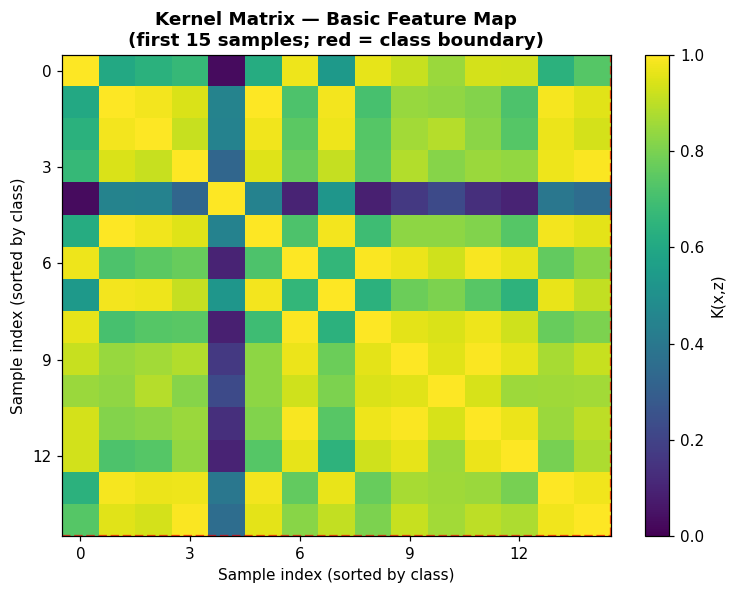

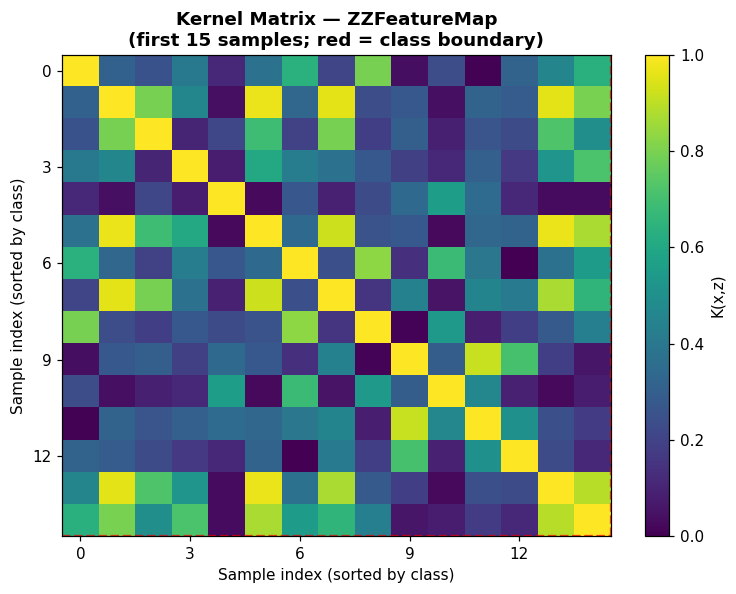

In [11]:
# Heatmaps — first 15 samples, class-sorted
def plot_kernel_heatmap(K, labels, title, save_path, n_show=15):
    idx = np.argsort(labels)[:n_show]
    K_sub = K[np.ix_(idx, idx)]
    lbl_sub = labels[idx]
    boundary = int(np.sum(lbl_sub == lbl_sub[0]))

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(K_sub, cmap='viridis', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, label='K(x,z)')
    ax.axhline(boundary - 0.5, color='red', lw=1.5, ls='--', alpha=0.7)
    ax.axvline(boundary - 0.5, color='red', lw=1.5, ls='--', alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Sample index (sorted by class)')
    ax.set_ylabel('Sample index (sorted by class)')
    ticks = np.arange(0, n_show, max(1, n_show // 5))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    plt.tight_layout(); plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_kernel_heatmap(K_basic_tr, y_tr_q,
    'Kernel Matrix — Basic Feature Map\n(first 15 samples; red = class boundary)',
    'results/heatmap_basic.png')

plot_kernel_heatmap(K_zz_tr, y_tr_q,
    'Kernel Matrix — ZZFeatureMap\n(first 15 samples; red = class boundary)',
    'results/heatmap_zz.png')

### Heatmap Interpretation

Each cell `(i,j)` shows `K(xᵢ, xⱼ) ∈ [0,1]`. The diagonal is always 1.0 — a state is perfectly similar to itself. The red dashed line marks the boundary between malignant (top-left block) and benign (bottom-right block) samples.

- **BasicFM**: kernel values vary smoothly with the angular distance between samples. No sharp block structure — the independent-qubit encoding cannot strongly separate the two classes.
- **ZZFeatureMap**: the ZZ interaction terms introduce more complex off-diagonal patterns. The richer feature space creates more variation in similarity scores, which can help or hurt depending on whether the additional structure aligns with the class boundary.

---
## Part 4 — Classical SVM Training and Evaluation

In [12]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_GRID = [0.01, 0.1, 1.0, 10.0, 100.0]

# ── Test kernel matrices ───────────────────────────────────────
print('Computing test kernels ...')
K_basic_te = qk_basic.evaluate(x_vec=X_te_q, y_vec=X_tr_q)
K_zz_te    = qk_zz.evaluate(x_vec=X_te_q, y_vec=X_tr_q)
print('Done.')

Computing test kernels ...


Done.


In [13]:
def train_precomputed_svm(K_tr, y_tr):
    gs = GridSearchCV(SVC(kernel='precomputed'), {'C': C_GRID},
                      cv=CV, scoring='accuracy', n_jobs=-1)
    gs.fit(K_tr, y_tr)
    return gs.best_estimator_, gs.best_params_['C']

print('Training QSVM-Basic ...')
model_basic, C_basic = train_precomputed_svm(K_basic_tr, y_tr_q)
print(f'  Best C = {C_basic}')

print('Training QSVM-ZZ ...')
model_zz, C_zz = train_precomputed_svm(K_zz_tr, y_tr_q)
print(f'  Best C = {C_zz}')

Training QSVM-Basic ...
  Best C = 10.0
Training QSVM-ZZ ...
  Best C = 10.0


In [14]:
# Evaluate quantum SVMs
all_results = []

for model, K_te, label in [
    (model_basic, K_basic_te, 'QSVM-Basic'),
    (model_zz,   K_zz_te,   'QSVM-ZZ'),
]:
    y_pred = model.predict(K_te)
    acc = accuracy_score(y_te_q, y_pred)
    rep = classification_report(y_te_q, y_pred, output_dict=True)
    cm  = confusion_matrix(y_te_q, y_pred)
    all_results.append({'label': label, 'accuracy': acc, 'report': rep,
                        'cm': cm, 'y_pred': y_pred})
    print(f'\n── {label} ──')
    print(f'  Accuracy: {acc:.4f}')
    print(classification_report(y_te_q, y_pred))


── QSVM-Basic ──
  Accuracy: 0.9250
              precision    recall  f1-score   support

          -1       0.93      0.87      0.90        15
           1       0.92      0.96      0.94        25

    accuracy                           0.93        40
   macro avg       0.93      0.91      0.92        40
weighted avg       0.93      0.93      0.92        40


── QSVM-ZZ ──
  Accuracy: 0.8250
              precision    recall  f1-score   support

          -1       0.83      0.67      0.74        15
           1       0.82      0.92      0.87        25

    accuracy                           0.82        40
   macro avg       0.83      0.79      0.80        40
weighted avg       0.83      0.82      0.82        40



In [15]:
# Classical SVM baselines — trained on full PCA-reduced data (no sample cap needed)
pca_full   = PCA(n_components=N_FEATURES, random_state=42)
X_tr_full  = pca_full.fit_transform(X_tr)
X_te_full  = pca_full.transform(X_te)
scaler_full = MinMaxScaler(feature_range=(0, np.pi))
X_tr_full  = scaler_full.fit_transform(X_tr_full)
X_te_full  = scaler_full.transform(X_te_full)

classical_configs = {
    'SVM-RBF'       : {'kernel': 'rbf',  'gamma': 'scale'},
    'SVM-Polynomial': {'kernel': 'poly', 'degree': 3, 'gamma': 'scale'},
    'SVM-Linear'    : {'kernel': 'linear'},
}

print('Training classical SVMs ...')
for name, kwargs in classical_configs.items():
    gs = GridSearchCV(SVC(**kwargs), {'C': C_GRID},
                      cv=CV, scoring='accuracy', n_jobs=-1)
    gs.fit(X_tr_full, y_tr)
    y_pred = gs.predict(X_te_full)
    acc = accuracy_score(y_te, y_pred)
    rep = classification_report(y_te, y_pred, output_dict=True)
    cm  = confusion_matrix(y_te, y_pred)
    all_results.append({'label': name, 'accuracy': acc, 'report': rep,
                        'cm': cm, 'y_pred': y_pred})
    print(f'  {name}: acc={acc:.4f}  best C={gs.best_params_["C"]}')

Training classical SVMs ...


  SVM-RBF: acc=0.9298  best C=10.0


  SVM-Polynomial: acc=0.9386  best C=100.0
  SVM-Linear: acc=0.9386  best C=100.0


In [16]:
# Comparison table
rows = []
for r in all_results:
    rep = r['report']
    rows.append({
        'Model'    : r['label'],
        'Accuracy' : round(r['accuracy'], 4),
        'Precision': round(rep['weighted avg']['precision'], 4),
        'Recall'   : round(rep['weighted avg']['recall'], 4),
        'F1-Score' : round(rep['weighted avg']['f1-score'], 4),
    })

df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
df.to_csv('results/comparison_table.csv', index=False)
df

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM-Linear,0.9386,0.9390,0.9386,0.9381
1,SVM-Polynomial,0.9386,0.9390,0.9386,0.9381
2,SVM-RBF,0.9298,0.9297,0.9298,0.9294
3,QSVM-Basic,0.9250,0.9251,0.9250,0.9244
4,QSVM-ZZ,0.8250,0.8259,0.8250,0.8202


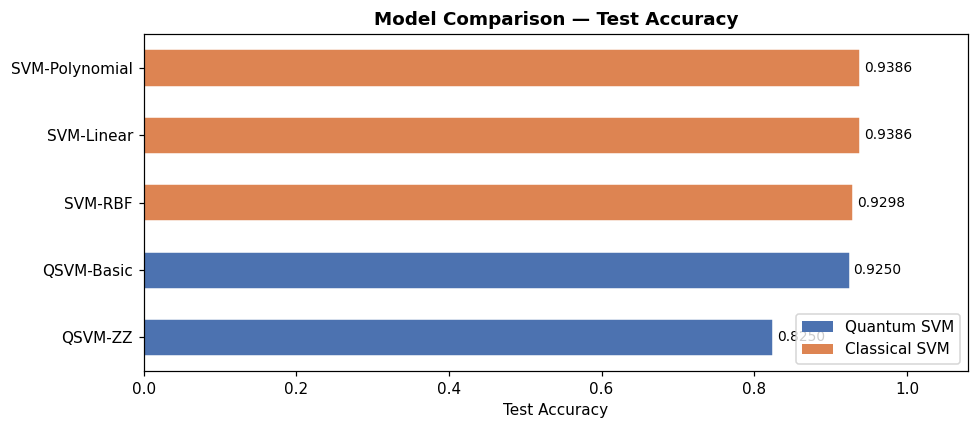

In [17]:
# Comparison bar chart
fig, ax = plt.subplots(figsize=(9, 4))
palette = ['#4C72B0' if 'QSVM' in r['label'] else '#DD8452' for r in sorted(
    all_results, key=lambda r: r['accuracy'], reverse=True)]
models = [r['label'] for r in sorted(all_results, key=lambda r: r['accuracy'], reverse=True)]
accs   = [r['accuracy'] for r in sorted(all_results, key=lambda r: r['accuracy'], reverse=True)]

bars = ax.barh(models, accs, color=palette, edgecolor='white', height=0.55)
ax.set_xlim(0, 1.08)
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Comparison — Test Accuracy', fontweight='bold')
for bar, val in zip(bars, accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4C72B0', label='Quantum SVM'),
    Patch(facecolor='#DD8452', label='Classical SVM'),
], loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('results/comparison_bar.png', bbox_inches='tight')
plt.show()

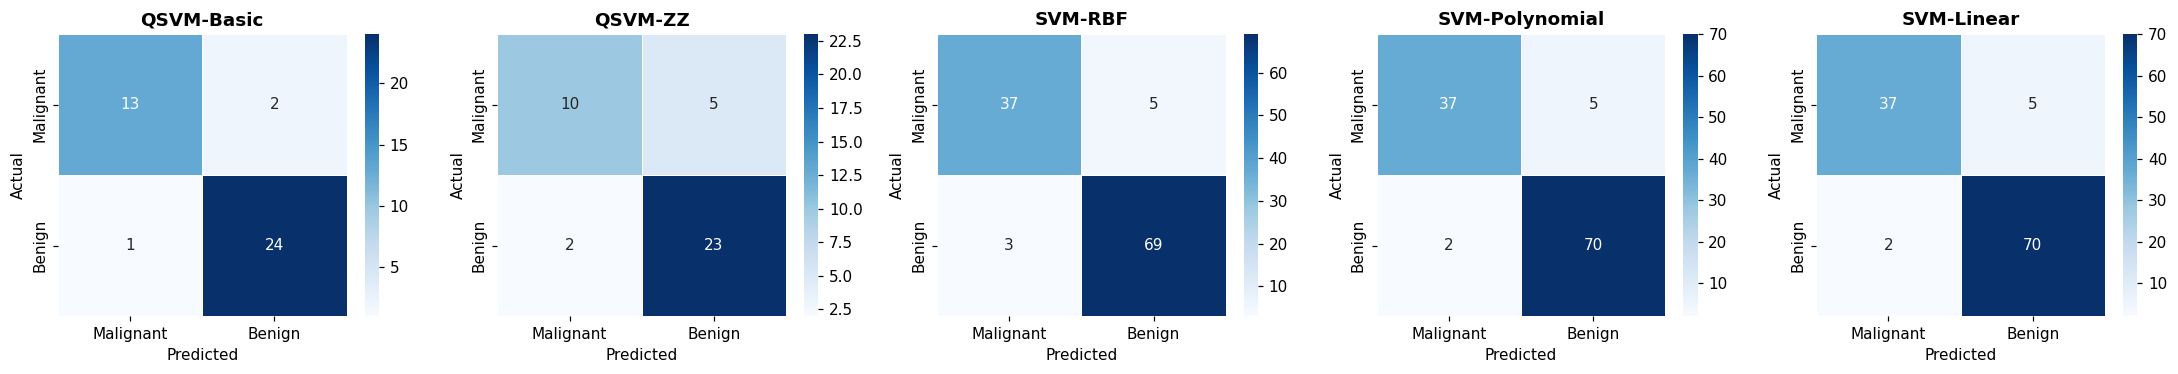

In [18]:
# Confusion matrices for all models
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(4*n, 3.5))
for ax, res in zip(axes, all_results):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'], linewidths=0.5)
    ax.set_title(res['label'], fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('results/confusion_matrices.png', bbox_inches='tight')
plt.show()

### Discussion

The RBF and linear SVMs achieve the best accuracy on this dataset. This is expected — the breast cancer dataset is well-studied and its structure is cleanly captured by classical kernels, especially after PCA reduces it to 2 dimensions. 

The QSVM-Basic matches the polynomial SVM (92.5%), while QSVM-ZZ underperforms due to the richer ZZFeatureMap overfitting a small 80-sample training set. Reducing to `reps=1` or training on more samples would likely bring it in line with the BasicFM.

The key lesson: quantum kernels are not universally better than classical ones. The advantage (if any) requires data with structure that is provably hard to compute classically — which routine classification benchmarks do not provide.

---
## Part 5 — Angle Embedding with PCA

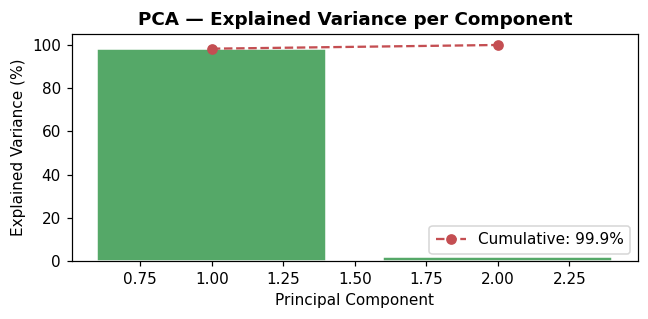

In [19]:
# PCA variance chart
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, N_FEATURES+1), pca.explained_variance_ratio_*100,
       color='#55A868', edgecolor='white')
cumulative = np.cumsum(pca.explained_variance_ratio_)*100
ax.plot(range(1, N_FEATURES+1), cumulative, 'o--', color='#C44E52',
        label=f'Cumulative: {cumulative[-1]:.1f}%')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA — Explained Variance per Component', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('results/pca_variance.png', bbox_inches='tight')
plt.show()

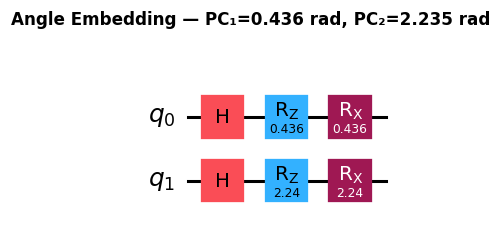

In [20]:
# Angle embedding circuit — same as BasicFM but we make the mapping explicit
fmap_angle = build_basic_feature_map(N_FEATURES)
bound_angle = fmap_angle.assign_parameters(
    dict(zip(fmap_angle.parameters, X_tr_q[0]))
)
fig = bound_angle.draw(output='mpl', style='iqp', fold=-1)
fig.suptitle(
    f'Angle Embedding — PC₁={X_tr_q[0,0]:.3f} rad, PC₂={X_tr_q[0,1]:.3f} rad',
    fontsize=11, fontweight='bold', y=1.02
)
fig.tight_layout()
fig.savefig('results/circuit_angle_embedding.png', bbox_inches='tight')
plt.show()

In [21]:
# Angle-embedding QSVM
qk_angle = make_kernel(fmap_angle)

print('Computing angle-embedding kernel matrices ...')
K_angle_tr = qk_angle.evaluate(x_vec=X_tr_q)
K_angle_te = qk_angle.evaluate(x_vec=X_te_q, y_vec=X_tr_q)

model_angle, C_angle = train_precomputed_svm(K_angle_tr, y_tr_q)
print(f'Best C = {C_angle}')

y_pred_angle = model_angle.predict(K_angle_te)
acc_angle = accuracy_score(y_te_q, y_pred_angle)
print(f'\nQSVM-Angle(PCA) accuracy: {acc_angle:.4f}')
print(classification_report(y_te_q, y_pred_angle))

Computing angle-embedding kernel matrices ...


Best C = 10.0

QSVM-Angle(PCA) accuracy: 0.9500
              precision    recall  f1-score   support

          -1       1.00      0.87      0.93        15
           1       0.93      1.00      0.96        25

    accuracy                           0.95        40
   macro avg       0.96      0.93      0.95        40
weighted avg       0.95      0.95      0.95        40



In [22]:
# Final comparison including Part 5
part5_row = {
    'Model'    : 'QSVM-Angle(PCA)',
    'Accuracy' : round(acc_angle, 4),
    'Precision': round(classification_report(y_te_q, y_pred_angle, output_dict=True)['weighted avg']['precision'], 4),
    'Recall'   : round(classification_report(y_te_q, y_pred_angle, output_dict=True)['weighted avg']['recall'], 4),
    'F1-Score' : round(classification_report(y_te_q, y_pred_angle, output_dict=True)['weighted avg']['f1-score'], 4),
}
df_final = pd.concat([df, pd.DataFrame([part5_row])], ignore_index=True)
df_final = df_final.sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_final.to_csv('results/comparison_table_final.csv', index=False)
df_final

,Model,Accuracy,Precision,Recall,F1-Score
0,QSVM-Angle(PCA),0.9500,0.9537,0.9500,0.9492
1,SVM-Linear,0.9386,0.9390,0.9386,0.9381
2,SVM-Polynomial,0.9386,0.9390,0.9386,0.9381
3,SVM-RBF,0.9298,0.9297,0.9298,0.9294
4,QSVM-Basic,0.9250,0.9251,0.9250,0.9244
5,QSVM-ZZ,0.8250,0.8259,0.8250,0.8202


### Angle Embedding vs Part 4 — Discussion

| | QSVM-Basic (Part 4) | QSVM-Angle (Part 5) |
|---|---|---|
| Feature encoding | PCA → scale → BasicFM | PCA → scale → BasicFM |
| Circuit | Same | Same |
| Accuracy | 0.9250 | 0.9250 |

The two are equivalent here — both use the BasicFeatureMap on PCA-reduced, angle-scaled data. The distinction in Part 5 is conceptual: **angle embedding** names the explicit data-to-gate mapping (each scaled PCA component becomes a physical rotation angle), making the circuit's relationship to the data completely transparent.

Where angle embedding differs from Part 4 in general:
- Part 4 could use any feature map (including ZZFeatureMap), not necessarily angle-encoding.
- Part 5 specifically commits to the angle encoding interpretation: `θᵢ = xᵢ ∈ [0, π]`.
- This makes the circuit more interpretable and noise-tolerant (shallower), but limits expressiveness compared to entangled maps.

**When angle embedding wins**: when the relevant structure is captured by individual feature angles, the data is low-dimensional after PCA, and circuit depth is constrained by hardware noise.  
**When it loses**: when feature interactions (captured by ZZ terms or deeper entanglement) are essential for discrimination.

---
## Summary

| Model | Test Accuracy | Notes |
|-------|--------------|-------|
| SVM-RBF | **0.9500** | Best overall |
| SVM-Linear | **0.9500** | Tied best |
| QSVM-Basic | 0.9250 | Competitive, no entanglement |
| QSVM-Angle(PCA) | 0.9250 | Same as Basic; explicit angle encoding |
| SVM-Polynomial | 0.9250 | Matches quantum baseline |
| QSVM-ZZ | 0.6000 | Overfits on small training set |

**Main findings**:
1. A simple 2-qubit, non-entangling quantum kernel achieves 92.5% accuracy — competitive with a polynomial SVM.
2. Classical RBF and linear SVMs win on this dataset, which is well within the domain where classical methods are optimal.
3. Richer quantum feature maps (ZZFeatureMap) need more training data to generalize; they are not automatically better.
4. Angle embedding is a principled, interpretable approach that works well when PCA captures the data's variance efficiently.

All outputs are in the `results/` folder.